In [93]:
#Se importan las librerias a utilizar

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [94]:
import chardet

#Carga de datos ADJUSTED DEF

with open("CasasEnVenta_Madrid_VarsAdjusted_DEF.csv", "rb") as f:
    result = chardet.detect(f.read())
    encoding_detected = result["encoding"]

datos_adjusted = pd.read_csv("CasasEnVenta_Madrid_VarsAdjusted_DEF.csv", encoding=encoding_detected, sep=';', index_col='id')
print(datos_adjusted.head(5))

     precio tipo_vivienda  metros_cuadrados_totales  metros_cuadrados_utiles  \
id                                                                             
1    650000          Piso                        78                       78   
2    525000          Piso                        70                       62   
3    795000          Piso                       127                      113   
4   3650000          Piso                       304                      290   
5   5100000         Ático                       310                      270   

    numero_baNos  numero_habitaciones                    estado  \
id                                                                
1            1.0                    2  Segunda mano/buen estado   
2            1.0                    1  Segunda mano/buen estado   
3            2.0                    5  Segunda mano/buen estado   
4            5.0                    4  Segunda mano/buen estado   
5            5.0                    4

## Análisis Datos NULOS

**0) Registro de meta-datos del dataset.**

Se usa el método .info() para obtener datos crudos sobre los atributos del dataset y su contenido.

In [95]:
# Vista de los tipos de datos y el tamaño del dataset (filas/registros y columnas/atributos).

datos_adjusted.info()

print("-------------------------------------")
print(f"Cantidad de filas: {datos_adjusted.shape[0]}")
print(f"Cantidad de columnas: {datos_adjusted.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
Index: 19248 entries, 1 to 19444
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   precio                    19248 non-null  int64  
 1   tipo_vivienda             19248 non-null  object 
 2   metros_cuadrados_totales  19248 non-null  int64  
 3   metros_cuadrados_utiles   19248 non-null  int64  
 4   numero_baNos              19247 non-null  float64
 5   numero_habitaciones       19248 non-null  int64  
 6   estado                    18900 non-null  object 
 7   tipo_urbanizacion         19236 non-null  object 
 8   planta                    15999 non-null  float64
 9   antigUedad                11857 non-null  float64
 10  interior                  14276 non-null  object 
 11  orientacion_sur           9485 non-null   object 
 12  ascensor                  18842 non-null  object 
 13  piscina                   16539 non-null  object 
 14  trastero   

In [96]:
print(datos_adjusted.columns)

Index(['precio', 'tipo_vivienda', 'metros_cuadrados_totales',
       'metros_cuadrados_utiles', 'numero_baNos', 'numero_habitaciones',
       'estado', 'tipo_urbanizacion', 'planta', 'antigUedad', 'interior',
       'orientacion_sur', 'ascensor', 'piscina', 'trastero', 'garaje',
       'terraza', 'balcon', 'jardin', 'armarios', 'padel',
       'aire_acondicionado', 'calefaccion', 'postal_code', 'geohash_6',
       'municipio'],
      dtype='object')


In [97]:
#Valores Nulos por caracteristica
for variable in datos_adjusted.columns:
    print(f"Conteo de valores nulos de la Variable {variable} :\n{datos_adjusted[variable].isnull().sum()}")

Conteo de valores nulos de la Variable precio :
0
Conteo de valores nulos de la Variable tipo_vivienda :
0
Conteo de valores nulos de la Variable metros_cuadrados_totales :
0
Conteo de valores nulos de la Variable metros_cuadrados_utiles :
0
Conteo de valores nulos de la Variable numero_baNos :
1
Conteo de valores nulos de la Variable numero_habitaciones :
0
Conteo de valores nulos de la Variable estado :
348
Conteo de valores nulos de la Variable tipo_urbanizacion :
12
Conteo de valores nulos de la Variable planta :
3249
Conteo de valores nulos de la Variable antigUedad :
7391
Conteo de valores nulos de la Variable interior :
4972
Conteo de valores nulos de la Variable orientacion_sur :
9763
Conteo de valores nulos de la Variable ascensor :
406
Conteo de valores nulos de la Variable piscina :
2709
Conteo de valores nulos de la Variable trastero :
5084
Conteo de valores nulos de la Variable garaje :
3946
Conteo de valores nulos de la Variable terraza :
3361
Conteo de valores nulos de l

<Axes: ylabel='id'>

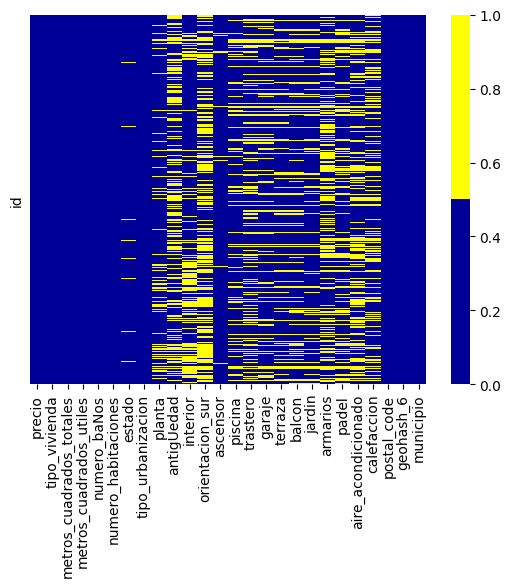

In [98]:
# Con este gráfico de barras de calor, podemos localizar muy facilmente aquellas variables que tienen nulos.
colours = ['#000099', '#ffff00'] # El color amarillo reprenta los valores nulos.
sns.heatmap(datos_adjusted[datos_adjusted.columns].isnull(), cmap=sns.color_palette(colours), yticklabels=False, cbar=True)
#sns.heatmap(datos_adjusted[datos_adjusted.columns].isnull(), cmap='viridis', yticklabels=False, cbar=True)
#AMARILLO ES NULO Y AZUL ES NO NULO

In [99]:
#porcentaje de nulos por variable
for col in datos_adjusted.columns:
    pct_missing = np.mean(datos_adjusted[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100, 3)))

precio - 0.0%
tipo_vivienda - 0.0%
metros_cuadrados_totales - 0.0%
metros_cuadrados_utiles - 0.0%
numero_baNos - 0.005%
numero_habitaciones - 0.0%
estado - 1.808%
tipo_urbanizacion - 0.062%
planta - 16.88%
antigUedad - 38.399%
interior - 25.831%
orientacion_sur - 50.722%
ascensor - 2.109%
piscina - 14.074%
trastero - 26.413%
garaje - 20.501%
terraza - 17.462%
balcon - 19.722%
jardin - 16.163%
armarios - 38.025%
padel - 22.569%
aire_acondicionado - 31.931%
calefaccion - 27.894%
postal_code - 0.0%
geohash_6 - 0.0%
municipio - 0.0%


REVISAMOS LAS VARIABLES DE UNA EN UNA PARA TOMAR MEJOR LAS DECISIONES Y PODER REVISARLO MEJOR

Para conocer los valores únicos por atributo y su distribución se usan los métodos .unique() y .value_counts()

.unique(): lista las ocurrencias de valores únicos en el atributo.

.value_counts(): por cada valor del atributo muestra la cantidad de filas que registran tal valor.


**Tipos nominales (string) - Analisis de Valores Nulos**

In [100]:
#Vista de los valores únicos para la variable "tipo_vivienda".

print(f"Valores presentes en el atributo: {datos_adjusted['tipo_vivienda'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['tipo_vivienda'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['tipo_vivienda'].isnull().sum()}")

#COMO HAY 0 VALORES NULOS, ESTA ESTA COMPLETA

Valores presentes en el atributo: ['Piso' 'Ático' 'Dúplex' 'Estudio' 'Loft' 'Chalet' 'Casa de Pueblo'
 'Finca Rústica' 'Sótano'] 

Conteo de ocurrencias por valor:
tipo_vivienda
Piso              12072
Chalet             4776
Ático               961
Dúplex              826
Estudio             366
Casa de Pueblo      111
Finca Rústica        99
Loft                 31
Sótano                6
Name: count, dtype: int64 

Conteo de valores nulos:
0


In [101]:
#Vista de los valores únicos para la variable "estado".

print(f"Valores presentes en el atributo: {datos_adjusted['estado'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['estado'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['estado'].isnull().sum()}")

#COMO HAY 348 VALORES NULOS, TENEMOS QUE DECIDIR QUE HACER CON ESTOS, SI PODEMOS ADMITIR LA INFORMACION NULA.
#Revisando dichas viviendas, nos encontramos que tampoco tiene la información de "antigUedad". Recuerdo que ya se asumió que las viviendas de "Obra Nueva"
#venían sin "año_construccion" y se asumió que "antigUedad" sería 0 años para estas. Muchas tienen pisicina, garaje, jardin, terraza..por lo que parecen Obras Nuevas
#He revisado varios ejemplos manualmente y son todos Obras Nuevas por lo que lo asumimos así y la "antigUedad" será 0.

Valores presentes en el atributo: ['Segunda mano/buen estado' 'Segunda mano/para reformar' 'Obra Nueva' nan] 

Conteo de ocurrencias por valor:
estado
Segunda mano/buen estado      14941
Segunda mano/para reformar     2458
Obra Nueva                     1501
Name: count, dtype: int64 

Conteo de valores nulos:
348


In [102]:
#Vista de los valores únicos para la variable "tipo_urbanizacion".

print(f"Valores presentes en el atributo: {datos_adjusted['tipo_urbanizacion'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['tipo_urbanizacion'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['tipo_urbanizacion'].isnull().sum()}")

#COMO HAY 12 VALORES NULOS, TENEMOS QUE DECIDIR QUE HACER CON ESTOS, SI PODEMOS ADMITIR LA INFORMACION NULA.
#"FINCA RUSTICA" será "INDEPENDIENTE". Los otros 6 registros tienen poca información, por lo que los he revisado y he decidido eliminarlos.

Valores presentes en el atributo: ['Edificio' 'Independiente' nan 'Urbanización'] 

Conteo de ocurrencias por valor:
tipo_urbanizacion
Edificio         14249
Independiente     4966
Urbanización        21
Name: count, dtype: int64 

Conteo de valores nulos:
12


In [103]:
#Vista de los valores únicos para la variable "planta".
print(f"Valores presentes en el atributo: {datos_adjusted['planta'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['planta'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['planta'].isnull().sum()}")

#COMO HAY 3243 VALORES NULOS, TENEMOS QUE DECIDIR QUE HACER CON ESTOS, SI PODEMOS ADMITIR LA INFORMACION NULA O SI SE PUEDE COMPELTAR UTILIZANDO LA LOGICA.
#2426 viviendas son Chalet, Casa de Pueblo o Finca Rústica; por lo que se han asumido como planta 0.
#Faltarian 811 registros con Planta a null que se decide después que hacer cone esto.

Valores presentes en el atributo: [ 2.  4.  5.  6.  8. -1.  1. 12.  3.  9.  7. nan  0. 10. 16. 17. 11. 20.
 13. 14. 18. 15. -2. 19. 24. 22.] 

Conteo de ocurrencias por valor:
planta
 1.0     4539
 2.0     3001
 0.0     2432
 3.0     2190
 4.0     1603
 5.0      885
 6.0      562
 7.0      320
 8.0      121
 9.0      117
-1.0       81
 10.0      53
 11.0      30
 12.0      22
 13.0      15
 14.0       6
 15.0       6
 16.0       3
-2.0        3
 22.0       3
 17.0       2
 18.0       2
 20.0       1
 19.0       1
 24.0       1
Name: count, dtype: int64 

Conteo de valores nulos:
3249


In [104]:
#Vista de los valores únicos para la variable "interior".
print(f"Valores presentes en el atributo: {datos_adjusted['interior'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['interior'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['interior'].isnull().sum()}")

#COMO HAY 4972 VALORES NULOS, TENEMOS QUE DECIDIR QUE HACER CON ESTOS, SI PODEMOS ADMITIR LA INFORMACION NULA.
#LA MAYORÍA SON EXTERIORES, SOBRE EL 90%. Ya que qes muy raro que sean viviendas en garajes, o que solo tengan ventanas 
#a un patio interior...en otros casos siempre serán "exterior".
#4472 son viviendas independientes tipo Chalet por lo que se pasan a "Exterior".
#Asumimos también que todo lo que sea chalet o ático también tienen que ser "Exterior" por definición.
#Quedán 482 valores nulos que a priori parecen que deberían ser "Exterior" pero aún no lo asumiremos.
#Hay varias viviendas que son "Dúplex" y otras de "Obra Nueva" que por normalidad son "Exterior", pero no lo podemos asumir.
#Tendremos que ver si podemos dejar estos "nulos" al modelo o los eliminamos.
#En 320 de esas vivienda tampoco viene la "antigUedad" ni la planta ni la orientación ni la calefacción, por lo que parece que falta bastante información.

Valores presentes en el atributo: ['Exterior' 'Interior' nan] 

Conteo de ocurrencias por valor:
interior
Exterior    12596
Interior     1680
Name: count, dtype: int64 

Conteo de valores nulos:
4972


In [105]:
#Vista de los valores únicos para la variable "orientacion_sur".

print(f"Valores presentes en el atributo: {datos_adjusted['orientacion_sur'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['orientacion_sur'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['orientacion_sur'].isnull().sum()}")

#COMO HAY 9763 VALORES NULOS, TENEMOS QUE DECIDIR QUE HACER CON ESTOS, SI PODEMOS ADMITIR LA INFORMACION NULA O ELIMINAMOS DICHA VARIABLE.
# Tiene demasiado valores nulos, más del 50%...LA ELIMINAMOS -- realmente tendré que hablar sobre que es una variable complicada 
# y no tenemos forma de estimarla de una forma coherente y basada en datos.

Valores presentes en el atributo: [nan 'Si' 'No'] 

Conteo de ocurrencias por valor:
orientacion_sur
Si    5520
No    3965
Name: count, dtype: int64 

Conteo de valores nulos:
9763


In [106]:
#Vista de los valores únicos para la variable "ascensor".

print(f"Valores presentes en el atributo: {datos_adjusted['ascensor'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['ascensor'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['ascensor'].isnull().sum()}")

#COMO HAY 406 VALORES NULOS, TENEMOS QUE DECIDIR QUE HACER CON ESTOS, SI PODEMOS ADMITIR LA INFORMACION NULA O COMO AJUSTAMOS
#Asumimos que los "Chalet" donde no venga explícito que hay Ascensor, es porque no tienen Ascensor. Ya solo quedan 115 viviendas con "ascensor" a Null
#Podemos Asumir también que "Obras Nuevas" ya llevan Ascensor, pero son pocos casos (solo 12). 
# Esto mismo lo podríamos aplicar para contrucciones después del 2000. ¿Alguna ley o algo?
#Por contra, las viviendas muy antiguas es muy probable que no tengan Ascensor...INVENT pero alfinal las elimino
#Además omitir esta información que si que es crucial, son indicativos de que es posible que no tengan ascensor
#TENEMOS QUE DECIDIR QUE HACER CON LOS NULOS, SI LOS ELIMINAMOS O QUE.

Valores presentes en el atributo: ['Si' 'No' nan] 

Conteo de ocurrencias por valor:
ascensor
Si    10544
No     8298
Name: count, dtype: int64 

Conteo de valores nulos:
406


In [107]:
#Vista de los valores únicos para la variable "piscina".

print(f"Valores presentes en el atributo: {datos_adjusted['piscina'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['piscina'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['piscina'].isnull().sum()}")

#DEMASIADOS NULOS, 2709 y consideramos que es una variable a tener en cuenta, por lo que la falta de información se asume como una negación
#He revisado incluso los chalets (que es más común que tengan piscina) y la mayoria no tienen y algunos tienen pero con coste extra.
#.LA FALTA DE INFORMACIÓN ES UNA NEGACIÓN."

Valores presentes en el atributo: ['No' 'Si' nan] 

Conteo de ocurrencias por valor:
piscina
No    11024
Si     5515
Name: count, dtype: int64 

Conteo de valores nulos:
2709


In [108]:
#Vista de los valores únicos para la variable "padel".

print(f"Valores presentes en el atributo: {datos_adjusted['padel'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['padel'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['padel'].isnull().sum()}")

#Muchos nulos 4344 y la mayoría es "NO", no hay ninguna que tenga "Si"; por lo que no aporta información esta variable. Se elimina.


Valores presentes en el atributo: ['No' nan] 

Conteo de ocurrencias por valor:
padel
No    14904
Name: count, dtype: int64 

Conteo de valores nulos:
4344


In [109]:
#Vista de los valores únicos para la variable "trastero".

print(f"Valores presentes en el atributo: {datos_adjusted['trastero'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['trastero'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['trastero'].isnull().sum()}")

#DEMASIADOS NULOS, 5084, pero en este caso si que la falta de información asumimos que es negación, por lo que los "nulos" serán "NO"

Valores presentes en el atributo: ['No' nan 'Si'] 

Conteo de ocurrencias por valor:
trastero
Si    7721
No    6443
Name: count, dtype: int64 

Conteo de valores nulos:
5084


In [110]:
#Vista de los valores únicos para la variable "garaje".

print(f"Valores presentes en el atributo: {datos_adjusted['garaje'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['garaje'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['garaje'].isnull().sum()}")

#DEMASIADOS NULOS, 3946, pero en este caso si que la falta de información asumimos como que es negación, por lo que los "nulos" serán "NO"

Valores presentes en el atributo: ['No' nan 'Si'] 

Conteo de ocurrencias por valor:
garaje
Si    8487
No    6815
Name: count, dtype: int64 

Conteo de valores nulos:
3946


In [111]:
#Vista de los valores únicos para la variable "terraza".

print(f"Valores presentes en el atributo: {datos_adjusted['terraza'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['terraza'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['terraza'].isnull().sum()}")

#DEMASIADOS NULOS, 3361, pero en este caso si que la falta de información asumimos como que es negación, por lo que los "nulos" serán "NO"

Valores presentes en el atributo: ['No' 'Si' nan] 

Conteo de ocurrencias por valor:
terraza
Si    9304
No    6583
Name: count, dtype: int64 

Conteo de valores nulos:
3361


In [112]:
#Vista de los valores únicos para la variable "balcon".

print(f"Valores presentes en el atributo: {datos_adjusted['balcon'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['balcon'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['balcon'].isnull().sum()}")

#DEMASIADOS NULOS, 3796, pero en este caso si que la falta de información asumimos como que es negación, por lo que los "nulos" serán "NO"

Valores presentes en el atributo: ['No' 'Si' nan] 

Conteo de ocurrencias por valor:
balcon
No    11320
Si     4132
Name: count, dtype: int64 

Conteo de valores nulos:
3796


In [113]:
#Vista de los valores únicos para la variable "jardin".

print(f"Valores presentes en el atributo: {datos_adjusted['jardin'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['jardin'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['jardin'].isnull().sum()}")

#DEMASIADOS NULOS, 3111, pero en este caso si que la falta de información asumimos como que es negación, por lo que los "nulos" serán "NO"

Valores presentes en el atributo: ['No' nan 'Si'] 

Conteo de ocurrencias por valor:
jardin
No    12072
Si     4065
Name: count, dtype: int64 

Conteo de valores nulos:
3111


In [114]:
#Vista de los valores únicos para la variable "armarios".

print(f"Valores presentes en el atributo: {datos_adjusted['armarios'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['armarios'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['armarios'].isnull().sum()}")

#DEMASIADOS NULOS, 7319, pero en este caso si que la falta de información asumimos como que es negación, por lo que los "nulos" serán "NO"

Valores presentes en el atributo: [nan 'Si' 'No'] 

Conteo de ocurrencias por valor:
armarios
Si    11837
No       92
Name: count, dtype: int64 

Conteo de valores nulos:
7319


In [115]:
#Vista de los valores únicos para la variable "aire_acondicionado".

print(f"Valores presentes en el atributo: {datos_adjusted['aire_acondicionado'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['aire_acondicionado'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['aire_acondicionado'].isnull().sum()}")

#DEMASIADOS NULOS, 6146, pero en este caso si que la falta de información asumimos como que es negación, por lo que los "nulos" serán "NO"

Valores presentes en el atributo: [nan 'Si' 'No'] 

Conteo de ocurrencias por valor:
aire_acondicionado
Si    10578
No     2524
Name: count, dtype: int64 

Conteo de valores nulos:
6146


In [116]:
#Vista de los valores únicos para la variable "calefaccion".

print(f"Valores presentes en el atributo: {datos_adjusted['calefaccion'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['calefaccion'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['calefaccion'].isnull().sum()}")



#DEMASIADOS NULOS, 5369, pero en este caso si que la falta de información asumimos como que es negación, por lo que los "nulos" serán "Sin Calefaccion"

Valores presentes en el atributo: [nan 'Individual' 'Central' 'Sin Calefaccion'] 

Conteo de ocurrencias por valor:
calefaccion
Individual         11371
Central             1434
Sin Calefaccion     1074
Name: count, dtype: int64 

Conteo de valores nulos:
5369


In [117]:
#Vista de los valores únicos para la variable "antigUedad".

print(f"Valores presentes en el atributo: {datos_adjusted['antigUedad'].unique()} \n")

#Vista de la cantidad de ocurrencias de cada valor.
print(f"Conteo de ocurrencias por valor:\n{datos_adjusted['antigUedad'].value_counts()} \n")

#Valores Nulos.
print(f"Conteo de valores nulos:\n{datos_adjusted['antigUedad'].isnull().sum()}")

#DEMASIADOS NULOS, 7391, y es una variable delicada ya que si que es bastante importante pues las casas más nuevas suelen necesitar menos reforma
# y están hechas de materiales más modernos; por lo que las casas más nuevas, suelen ser más caras, además del propio uso del inmueble, pues a menos años, menos uso.
# lo que podemos hacer es utilizar la zona para ponerle la media de antiguedad del resto de viviendas. Primero le atribuiremos la media de su geohash; si no existen más viviendas
# en dicho geohash, entonces atribuiremos la media de antiguedad de las viviendas de su CP y por ende, de su municipio. 
# Finalmente, se atrubuirá la media de antiguedad de todas las viviendas de Madrid si no existe otra media más segmentada a la zona de la vivienda.
# para intentar ser un poco más preciso, se hará una media ponderada ya que a mayor segmentación, menos volumen de viviendas habrá. 
# geohash < cp < municipio y las medias pueden estar muy sesgadas por tener poco volumen de muestra. Por lo que daremos pesos a cada segmentacion con un reparto de esta forma:
# 1) media_geohash*(0,35) + media_cp*(0,45) +  media_municipio*(0,2)
# 2) media_cp*(0,7) +  media_municipio*(0,3)
# 3) media_municipio*(0,7) + media_Madrid_Provincia*(0,2)
# 4) media_Madrid_Provincia*(1,0)

Valores presentes en el atributo: [ nan  85.  59.  56. 125.  75.  95.   0.  57.  96.   7.  65.  70.  79.
  29.  86.  61.  67.  35.  55. 106.  10. 138.   3.  63.  80.  60.  68.
  11.  58.  37.  50. 116.  48.  45. 120.  78.  52. 115.  69.  77.  99.
 105.  23.  40.  47.  43.  30.  73.  21.  66.  31.  49.  94.  36.  20.
  92.  90.  71.  39.   5. 100.  89.  42.  98.  97.  76.  84.  93.  53.
 109.  46.  51.   1.  34. 107.  18. 133.  83.  62.  54.   2.   8.  24.
  64.  22.  41.  17.  33.  32.  19.   4.   6.  14.  25.  12.  26.  15.
  27.   9.  16.  44.  28.  38. 225.  13. 112. 121.  72. 102. 175.  82.
  74. 110. 101. 103.  81. 135.  91. 136. 108. 111. 124. 113. 134.  87.
 171. 127. 145. 165. 119. 132. 123. 169. 150. 155. 137. 128. 104. 141.
 164. 205. 118. 157. 142. 117. 122.] 

Conteo de ocurrencias por valor:
antigUedad
0.0      1549
125.0     490
55.0      345
65.0      328
18.0      278
         ... 
132.0       1
119.0       1
134.0       1
87.0        1
122.0       1
Name: count, Length

In [118]:
#Carga de datos VarsNotNulls

with open("CasasEnVenta_Madrid_VarsNotNulls.csv", "rb") as f:
    result = chardet.detect(f.read())
    encoding_detected = result["encoding"]

datos_vars_not_nulls= pd.read_csv("CasasEnVenta_Madrid_VarsNotNulls.csv", encoding=encoding_detected, sep=';', index_col='id')
print(datos_vars_not_nulls.head(5))

     precio  metros_cuadrados_totales  metros_cuadrados_utiles  numero_baNos  \
id                                                                             
1    650000                        78                       78             1   
2    525000                        70                       62             1   
3    795000                       127                      113             2   
4   3650000                       304                      290             5   
5   5100000                       310                      270             5   

    numero_habitaciones  planta  antigUedad tipo_urbanizacion tipo_vivienda  \
id                                                                            
1                     2       2          66          Edificio          Piso   
2                     1       4          57          Edificio          Piso   
3                     5       4          54          Edificio          Piso   
4                     4       5          85 

In [119]:
print(datos_vars_not_nulls.columns)

Index(['precio', 'metros_cuadrados_totales', 'metros_cuadrados_utiles',
       'numero_baNos', 'numero_habitaciones', 'planta', 'antigUedad',
       'tipo_urbanizacion', 'tipo_vivienda', 'estado', 'interior', 'ascensor',
       'piscina', 'trastero', 'garaje', 'terraza', 'balcon', 'jardin',
       'armarios', 'aire_acondicionado', 'calefaccion', 'geohash_6',
       'postal_code', 'municipio'],
      dtype='object')


<Axes: ylabel='id'>

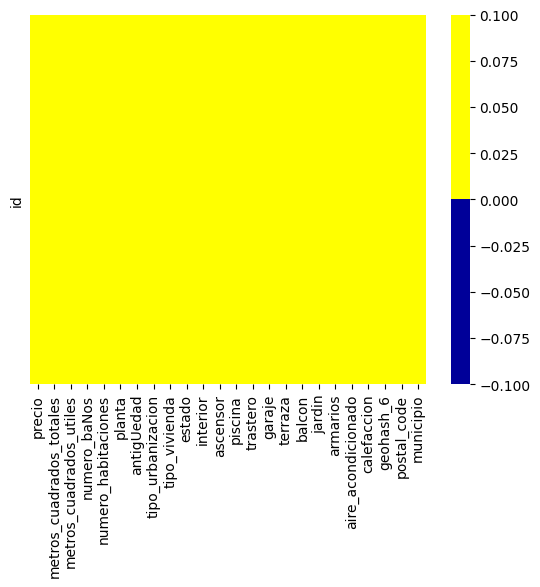

In [120]:
# Con este gráfico de barras de calor, podemos localizar muy facilmente aquellas variables que tienen nulos.
colours = ['#000099', '#ffff00'] # El color amarillo reprenta los valores nulos.
sns.heatmap(datos_vars_not_nulls[datos_vars_not_nulls.columns].isnull(), cmap=sns.color_palette(colours), yticklabels=False, cbar=True)
#sns.heatmap(datos_vars_not_nulls[datos_vars_not_nulls.columns].isnull(), cmap='viridis', yticklabels=False, cbar=True)
#AMARILLO ES NULO Y AZUL ES NO NULO

In [121]:
#porcentaje de nulos por variable
for col in datos_vars_not_nulls.columns:
    pct_missing = np.mean(datos_vars_not_nulls[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100, 3)))

precio - 0.0%
metros_cuadrados_totales - 0.0%
metros_cuadrados_utiles - 0.0%
numero_baNos - 0.0%
numero_habitaciones - 0.0%
planta - 0.0%
antigUedad - 0.0%
tipo_urbanizacion - 0.0%
tipo_vivienda - 0.0%
estado - 0.0%
interior - 0.0%
ascensor - 0.0%
piscina - 0.0%
trastero - 0.0%
garaje - 0.0%
terraza - 0.0%
balcon - 0.0%
jardin - 0.0%
armarios - 0.0%
aire_acondicionado - 0.0%
calefaccion - 0.0%
geohash_6 - 0.0%
postal_code - 0.0%
municipio - 0.0%


FIN PRIMERA PARTE (YA NO HAY NULOS), CONTINUAMOS CON LA SEGUNDA

**- Variables Irrelevantes**

Ahora pasamos a analizar variables desinformativas

Se pueden tener características innecesarias ya que la información que presentan no ofrece un valor diferencial al modelo.

Por ejemplo, una característica puede tener el 95% de registros con el mismo valor, presentando muy poca variabilidad. En estos casos, se podría eliminar dicha variable del dataset para optimizar el modelo mejorando en rendimiento y reduciendo su coste computacional.

En otras palabras, sería encontrar aquellas variables "sesgadas" por los datos que presentan y decidir si se eliminan del conjunto de datos o como se deben tratar.

Es un proceso que depende totalmente del analista y la idea es marcar el **porcentaje de desinformación** suficiente que tiene que tener una característica para marcarla como **irrelevante**.

Llegados a este punto, las variables del conjunto de datos ya son todas relevantes, pero se deben analizar con profundidad para averiguar si los datos están sesgados o no.

En este caso, se ha decidido que el **porcentaje de desinformación** sea un 70%. De manera que tendremos que decidir que hacer con aquellas características que tengan más del 70% de registros con el mismo valor. Habrá que conseguir clases balanceadas, reduciendo aquellas clases de mayor volumen o añadiendo "semillas", datos generados de las clases/categorías menos voluminosas...Pero ambas categorías tienen sus pros y sus contras ya que la primera reducirá muchísimo la muestra y la segunda opción estará metiendo mucho sesgo por duplicar resultados identicos de una misma clase.

In [122]:
#revisamos las variables que no cumplen con el umbral permitido de "desinformacion"
num_rows = len(datos_vars_not_nulls.index)
low_information_cols = []

for col in datos_vars_not_nulls.columns:
    cnts = datos_vars_not_nulls[col].value_counts(dropna=False)
    top_pct = (cnts/num_rows).iloc[0]    
    if top_pct > 0.70:
        low_information_cols.append(col)
        print('{0}: {1:.5f}%'.format(col, top_pct*100),"\n")
        print(cnts, "\n")
if len(low_information_cols)==0:
    print("No se han encontrado características con más de un 70% de registros con el mismo valor.")

tipo_urbanizacion: 72.59853% 

tipo_urbanizacion
Edificio         13226
Independiente     4971
Urbanización        21
Name: count, dtype: int64 

estado: 77.41794% 

estado
Segunda mano/buen estado      14104
Segunda mano/para reformar     2393
Obra Nueva                     1721
Name: count, dtype: int64 

interior: 91.60171% 

interior
No    16688
Si     1530
Name: count, dtype: int64 

piscina: 70.43034% 

piscina
No    12831
Si     5387
Name: count, dtype: int64 

balcon: 77.74179% 

balcon
No    14163
Si     4055
Name: count, dtype: int64 

jardin: 77.76924% 

jardin
No    14168
Si     4050
Name: count, dtype: int64 



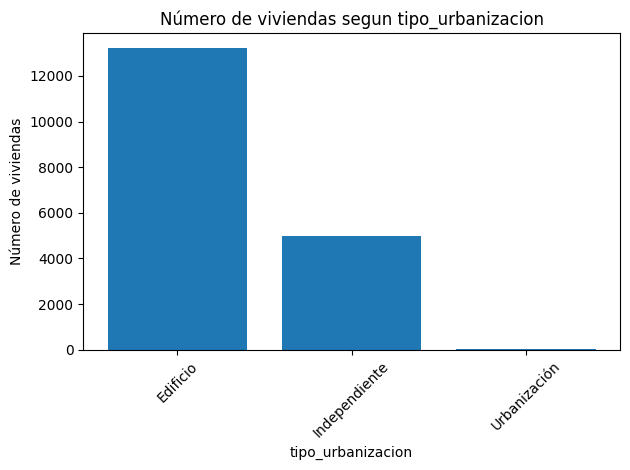

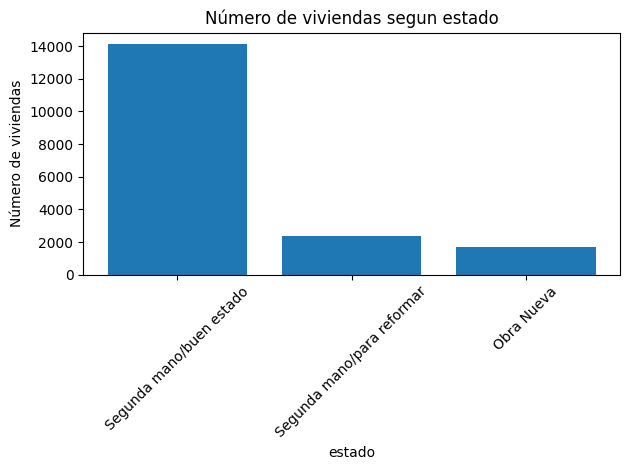

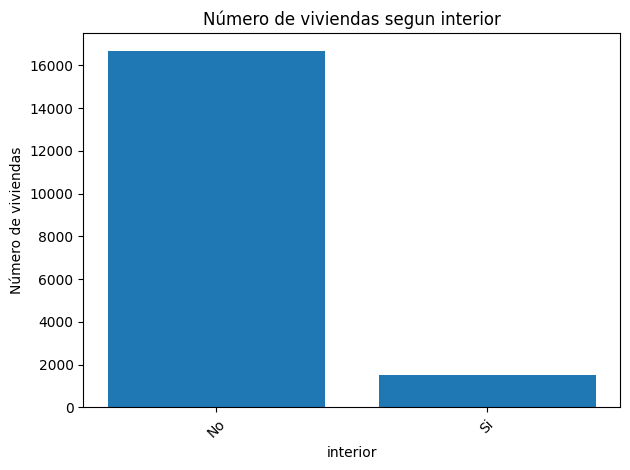

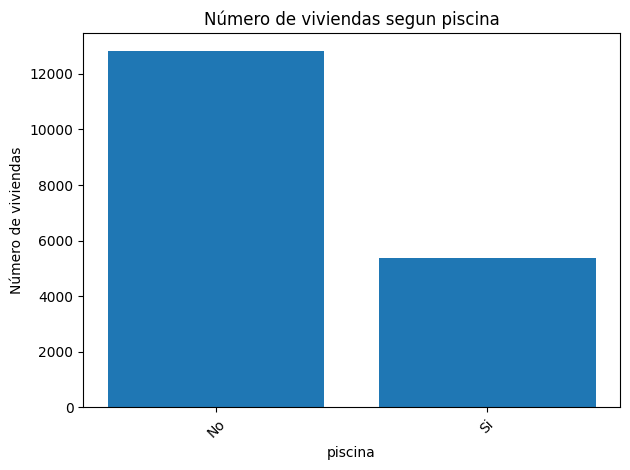

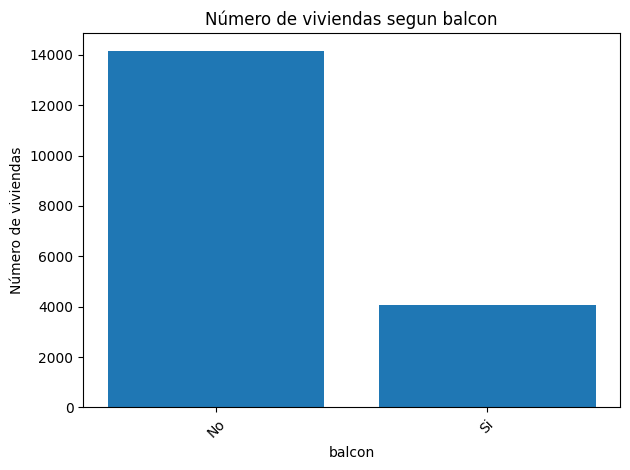

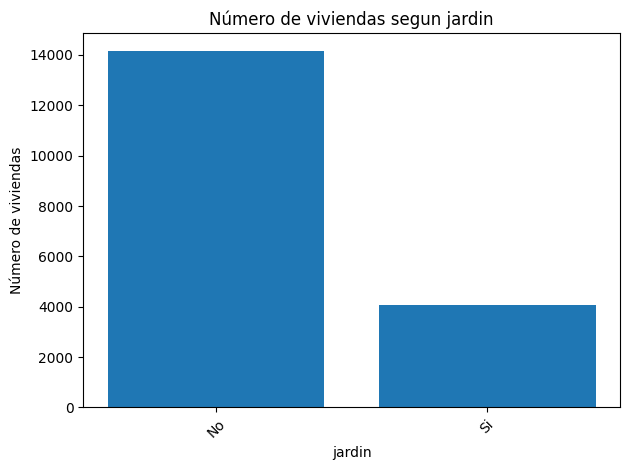

In [123]:

for var in low_information_cols:
    # Contar viviendas por tipo_urbanizacion
    conteo = datos_vars_not_nulls[var].value_counts()

    # Barplot simple
    plt.bar(conteo.index, conteo.values)
    plt.xlabel(str(var))
    plt.ylabel("Número de viviendas")
    plt.title("Número de viviendas segun "+str(var))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

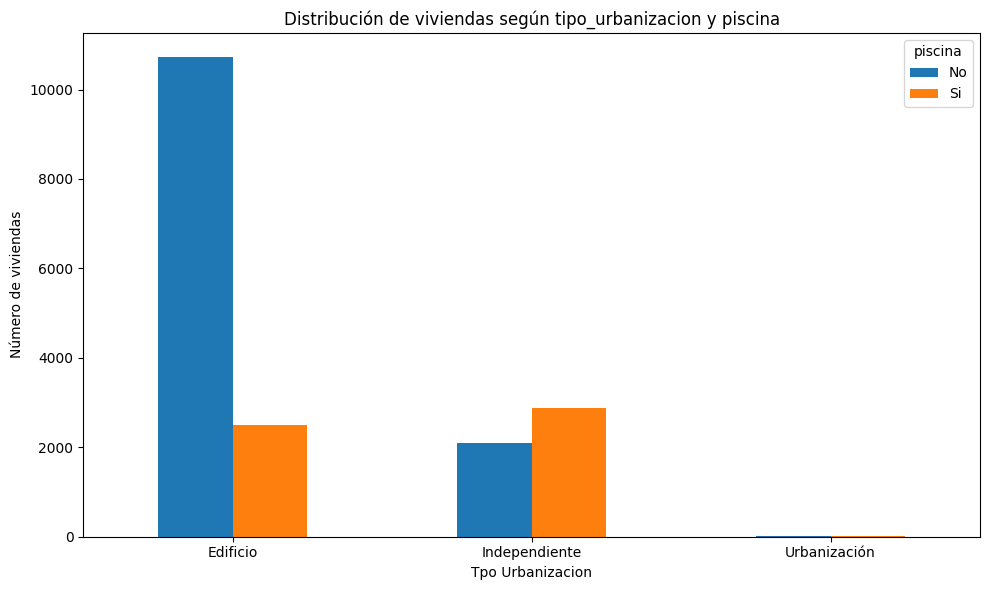

In [124]:

# Tabla de contingencia
tabla = pd.crosstab(datos_vars_not_nulls["tipo_urbanizacion"], datos_vars_not_nulls["piscina"])

# Barplot
tabla.plot(kind="bar", figsize=(10,6))

plt.xlabel("Tpo Urbanizacion")
plt.ylabel("Número de viviendas")
plt.title("Distribución de viviendas según tipo_urbanizacion y piscina")
plt.xticks(rotation=0)
plt.legend(title="piscina")
plt.tight_layout()
plt.show()



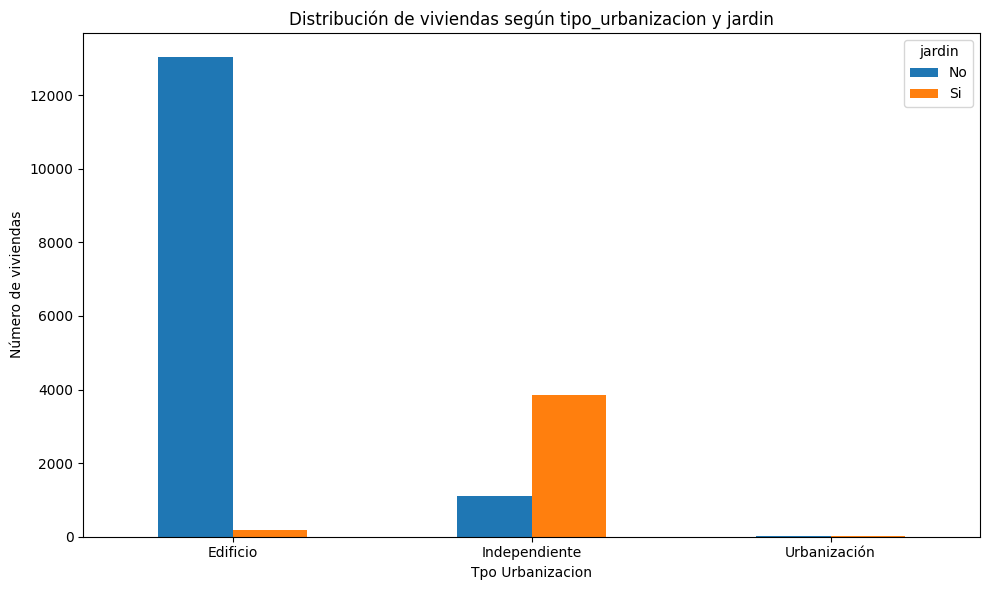

In [125]:

# Tabla de contingencia
tabla = pd.crosstab(datos_vars_not_nulls["tipo_urbanizacion"], datos_vars_not_nulls["jardin"])

# Barplot
tabla.plot(kind="bar", figsize=(10,6))

plt.xlabel("Tpo Urbanizacion")
plt.ylabel("Número de viviendas")
plt.title("Distribución de viviendas según tipo_urbanizacion y jardin")
plt.xticks(rotation=0)
plt.legend(title="jardin")
plt.tight_layout()
plt.show()

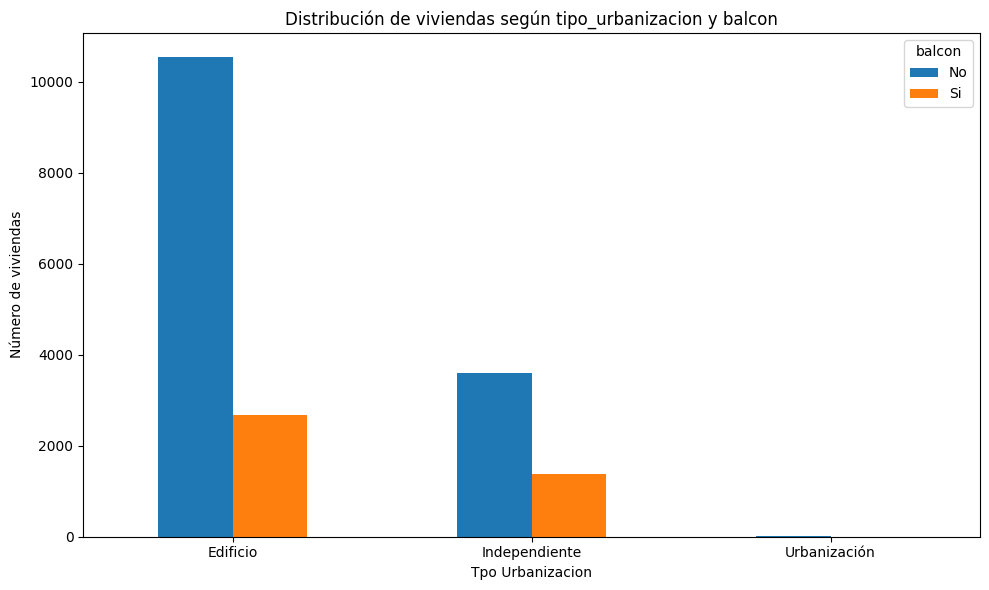

In [126]:

# Tabla de contingencia
tabla = pd.crosstab(datos_vars_not_nulls["tipo_urbanizacion"], datos_vars_not_nulls["balcon"])

# Barplot
tabla.plot(kind="bar", figsize=(10,6))

plt.xlabel("Tpo Urbanizacion")
plt.ylabel("Número de viviendas")
plt.title("Distribución de viviendas según tipo_urbanizacion y balcon")
plt.xticks(rotation=0)
plt.legend(title="balcon")
plt.tight_layout()
plt.show()

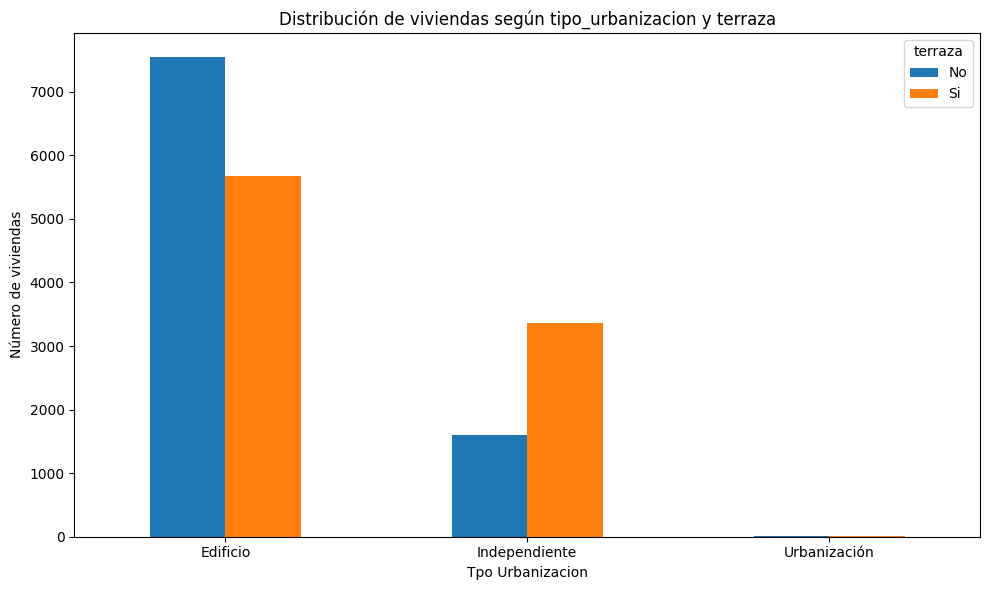

In [127]:

#revisamos tambien "terraza" para corroborar que "balcon" es un elemento que no depende del "tipo_urbanizacion" pero "terraza" si.

# Tabla de contingencia
tabla = pd.crosstab(datos_vars_not_nulls["tipo_urbanizacion"], datos_vars_not_nulls["terraza"])

# Barplot
tabla.plot(kind="bar", figsize=(10,6))

plt.xlabel("Tpo Urbanizacion")
plt.ylabel("Número de viviendas")
plt.title("Distribución de viviendas según tipo_urbanizacion y terraza")
plt.xticks(rotation=0)
plt.legend(title="terraza")
plt.tight_layout()
plt.show()

-Las variables a revisar por ser posibles "irrelevantes" (que quizás no aporten información clara y suficiente al modleo y se aporte complejidad y ruido) que superan el umbral de "desinformacion" aceptable son: "interior" (91,6%), "jardin (77,8%), "balcon" (77,7%), "estado" (77,4%), "tipo_urbanizacion" (72,6%) y "piscina" (70,4%).

-La variable más sesgada es "interior", pues más del 90% de las viviendas son "exteriores" como era de esperar (pues las viviendas necesitan minimos de luminosidad, ventilacion y al menos algun ventana debe dar al exterior...). ¿TIENE SENTIDO ELIMINAR ESTA CARACTERISTICA?

-La variable "tipo_urbanizacion" presenta la casuística que solo 21 viviendas están clasificadas como "urbanización" y llama la atencion que haya tan pocos registros aunque es una agrupación social más novedosa que comenzó a coger carrerilla a partir del 2000...Pensandolo bien, tiene lógica que el volumen predominante caiga sobre los Edificios y después, en volumen bastante más inferior, las viviendas independientes/unifamiliares (chalets, casas de "pueblo"...). Además, puede ser una variable algo confusa pues el formato "urbanizacion" y "edificio" practicamente es lo mismo según su forma de construcción (pisos que normalmente tienen ascensor, más de 3-4 plantas, escaleras comuntarias, portal comunitario...), con la particularidad que las urbanziaciones son un grupo de edificios que comparten más zonas comunes como garaje, jardin, piscina y otros usos. ¿QUIZÁS SERÍA SENSATO ELIMINAR EL TIPO_URBANIZACION", LAS "URBANIZACIONES" CLASIFICARLAS COMO "EDIFICIOS"/"PISOS" Y REALMENTE ACLARA QUE DICHA VARIABLE PRETENDE DIFERENCIA LAS VIVIENDAS "INDEPENDIENTES"/"UNIFAMILIAR"?

-Las variables "estado", "piscina", "jardin", "balcon" tienen un balanceo desconforme entre el 80% y el 70%, lo que es bastante alto, pero aceptable ya que tiene lógica. La variable "estado" esta sugestionada ya que la mayoria de viviendas suelen anunciarse como "buen estado" pues es una característica superflua que depende de de interpretación según la persona y evidentemente si quieres llamar la atención del futuro comprador, suele "maquillarse" el anuncio y poner "en buen estado" aunque la pintura ya no esté bien, los suelos, puertas, ventanas y muebles sean muy antiguos...en definitiva, se podria vivir en esa vivienda pero la realidad que esta muy anticuado y si que habría que invertir. En cambio, la variable "piscina" si que tiene un razonamiento más lógico, pues las casas más antiguas no tenían piscina y como además la tipología de las viviendas predominante es "Edificios"; este formato de vivienda no suele incluir piscina. Y de hecho, si analizamos la tipología de las viviendas según tienen piscina o no encontramos lo que buscábamos si filtramos por viviendas tipo "edificio" el porcentaje de viviendas con piscina es ínfimo y, sin embargo, las viviendas con piscina son la mayoriá para el formato "vivienda independiente".
A la variable "jardin" le sucede muy parecido a "piscina"; está muy sesgadas por la tipologia de urbanizacion; pues las viviendas "independientes" son más propensas a tener "jardin" mientras que en el formato "edificio" son características menos comunes.

-Por otro lado esta la variables "balcon" que no depende claramente del tipo de urbanización (edificio vs independiente), si no que aquí la mayoría de viviendas no tienen balcón (el 77,7%) pero predominan notablemente viviendas sin balcon tanto en "edificios" como en viviendas independientes.


¡¡¡¡¡Tendremos que decidir que haremos con estas variables, que a priori vamos a dejar. Decidirimos si la utilizamos finalmente en el modelo o no cuando veamos su correlación!!!!!

-El resto de variables serían aptas en cuanto al umbral de desinfomración impuesto del 70%.


Conclusión del análisis de variables desinformativas
Tras este proceso, se concluye que, a pesar de presentar distribuciones sesgadas, las variables analizadas responden en su mayoría a patrones reales del mercado inmobiliario y aportan información relevante para el modelado del precio de la vivienda. La única excepción es la variable tipo_urbanización, que ha sido transformada para capturar de forma más adecuada la estructura del inmueble. La decisión final sobre la inclusión o exclusión de estas variables se realizará tras el análisis de correlación y la evaluación de su importancia en los modelos predictivos.